# Introduction and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sktime.utils.plotting import plot_series
from sktime.datasets import load_uschange, load_basic_motions


## Intro

### Time Series Data

In [2]:
df = pd.read_csv("imdb_ts.csv", index_col=0)


In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,rating,genre,rating_category
id,,,,,,,,,,,,,,,,,,,,,
tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0,8.3,"['Adventure', 'Sci-Fi']",High
tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,637.0,734.0,857.0,785.0,724.0,713.0,699.0,7.1,"['Crime', 'Drama', 'Romance']",High
tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0,8.7,"['Documentary', 'Music']",High
tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0,7.4,"['Action', 'Adventure', 'Sci-Fi']",High
tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0,7.3,"['Adventure', 'Comedy', 'Drama']",High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt9731534,1077363.0,1061148.0,1043451.0,912840.0,738595.0,508118.0,296236.0,318113.0,341113.0,310422.0,...,2396.0,2425.0,2461.0,2223.0,1920.0,1991.0,2051.0,6.4,"['Horror', 'Mystery', 'Thriller']",Medium
tt9735462,56775.0,57750.0,58828.0,53549.0,48484.0,37340.0,19243.0,30804.0,55897.0,40874.0,...,739.0,618.0,488.0,636.0,883.0,904.0,920.0,6.3,"['Biography', 'Comedy', 'Drama']",Medium
tt9764362,3595005.0,3401235.0,3221227.0,2645775.0,2188725.0,1681250.0,1030698.0,1138724.0,1290788.0,1204996.0,...,345246.0,257388.0,182883.0,165311.0,144119.0,128009.0,111756.0,7.2,"['Comedy', 'Horror', 'Thriller']",High


In [4]:
print(df.columns)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '93', '94', '95', '96', '97', '98', '99', 'rating', 'genre',
       'rating_category'],
      dtype='object', length=103)


In [5]:
ts = df.iloc[:, :100]


In [6]:
ts.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,13925.0,14370.0,12577.0,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0
tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0
tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,16273.0,14396.0,10518.0,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0
tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,28490.0,24336.0,22421.0,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0
tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,43164.0,55339.0,69774.0,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0


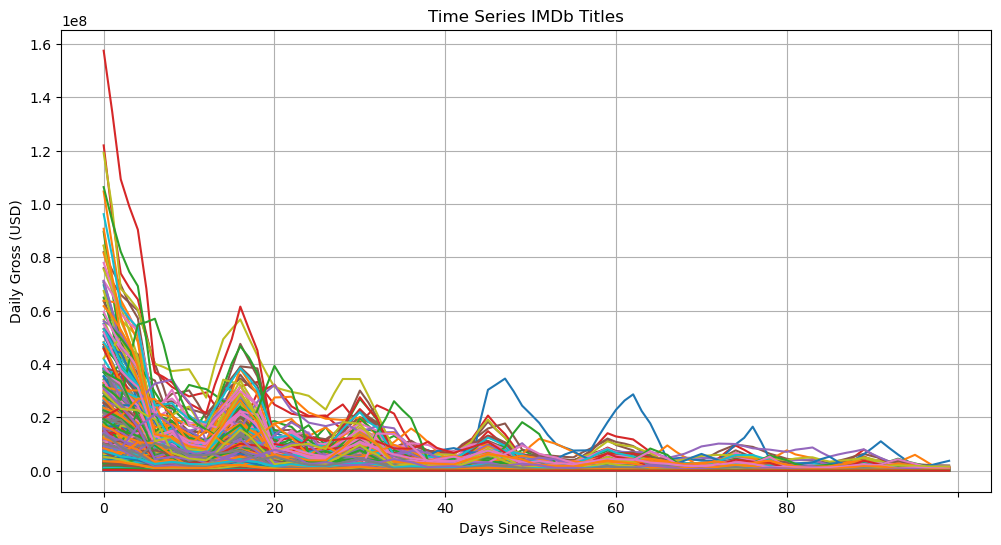

In [7]:
ts.T.plot(figsize=(12, 6), legend=False)
plt.title("Time Series IMDb Titles")
plt.xlabel("Days Since Release")
plt.ylabel("Daily Gross (USD)")
plt.grid(True)

plt.show()

Most time series decrease over time: The dominant pattern is a sharp drop in revenue after release (Day 0), which flattens out over the next 100 days.

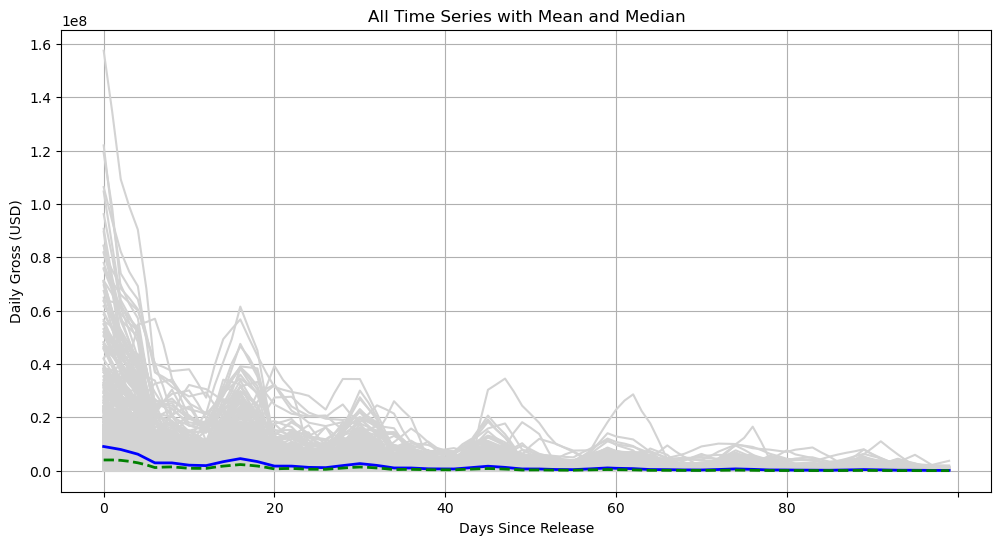

In [8]:

# All lines
ts.T.plot(figsize=(12, 6), color='lightgray',  legend=False)
# Mean trend
ts.mean().plot(color='blue', linewidth=2, label='Mean')
# Median trend
ts.median().plot(color='green', linestyle='--', linewidth=2, label='Median')
plt.title("All Time Series with Mean and Median")
plt.xlabel("Days Since Release")
plt.ylabel("Daily Gross (USD)")
plt.grid(True)
plt.show()


## Some basic statistics

In [9]:
ts.shape

(1134, 100)

In [10]:
len(ts)

1134

In [11]:
ts.index

Index(['tt0062622', 'tt0064816', 'tt0088178', 'tt0145487', 'tt0359950',
       'tt0369610', 'tt0435651', 'tt0437086', 'tt0439572', 'tt0448115',
       ...
       'tt9603212', 'tt9620288', 'tt9620292', 'tt9663764', 'tt9682428',
       'tt9731534', 'tt9735462', 'tt9764362', 'tt9784798', 'tt9883996'],
      dtype='object', name='id', length=1134)

In [12]:
ts.values

array([[5.705700e+04, 6.546900e+04, 7.164200e+04, ..., 1.240400e+04,
        1.367900e+04, 1.505600e+04],
       [1.923000e+03, 2.422000e+03, 2.853000e+03, ..., 7.240000e+02,
        7.130000e+02, 6.990000e+02],
       [3.329250e+05, 3.025030e+05, 2.672640e+05, ..., 1.121200e+04,
        9.010000e+03, 6.431000e+03],
       ...,
       [3.595005e+06, 3.401235e+06, 3.221227e+06, ..., 1.441190e+05,
        1.280090e+05, 1.117560e+05],
       [5.281670e+05, 6.174090e+05, 6.961270e+05, ..., 3.752000e+03,
        5.237000e+03, 6.592000e+03],
       [2.604290e+05, 2.960610e+05, 3.276980e+05, ..., 1.826000e+03,
        2.176000e+03, 2.417000e+03]])

In [13]:
ts.to_numpy()

array([[5.705700e+04, 6.546900e+04, 7.164200e+04, ..., 1.240400e+04,
        1.367900e+04, 1.505600e+04],
       [1.923000e+03, 2.422000e+03, 2.853000e+03, ..., 7.240000e+02,
        7.130000e+02, 6.990000e+02],
       [3.329250e+05, 3.025030e+05, 2.672640e+05, ..., 1.121200e+04,
        9.010000e+03, 6.431000e+03],
       ...,
       [3.595005e+06, 3.401235e+06, 3.221227e+06, ..., 1.441190e+05,
        1.280090e+05, 1.117560e+05],
       [5.281670e+05, 6.174090e+05, 6.961270e+05, ..., 3.752000e+03,
        5.237000e+03, 6.592000e+03],
       [2.604290e+05, 2.960610e+05, 3.276980e+05, ..., 1.826000e+03,
        2.176000e+03, 2.417000e+03]])

In [14]:
ts.describe(include='all')

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
count,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,...,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03,1.134000e+03
mean,9.075217e+06,8.521398e+06,7.954433e+06,7.080579e+06,6.200350e+06,4.567772e+06,2.943717e+06,2.932913e+06,2.929824e+06,2.503033e+06,...,3.735494e+05,3.173743e+05,2.546920e+05,1.909471e+05,1.804780e+05,1.711978e+05,1.457827e+05,1.192445e+05,1.153249e+05,1.111532e+05
std,1.559543e+07,1.366932e+07,1.188300e+07,1.066701e+07,9.596818e+06,7.180084e+06,5.160170e+06,4.787618e+06,4.569201e+06,4.050967e+06,...,7.050432e+05,6.415705e+05,5.310139e+05,4.772244e+05,4.025968e+05,3.688206e+05,2.941344e+05,2.332032e+05,2.303428e+05,2.333821e+05
min,1.266000e+03,2.422000e+03,2.853000e+03,2.947000e+03,3.054000e+03,2.844000e+03,1.940000e+03,1.865000e+03,1.277000e+03,1.449000e+03,...,3.400000e+01,3.500000e+01,3.500000e+01,1.200000e+01,3.000000e+01,2.200000e+01,2.700000e+01,2.800000e+01,3.600000e+01,8.000000e+00
25%,4.618975e+05,4.531445e+05,4.673408e+05,4.031570e+05,3.583830e+05,2.618655e+05,1.592525e+05,1.908358e+05,2.043262e+05,1.841965e+05,...,2.546775e+04,2.182375e+04,1.651875e+04,9.954500e+03,1.058575e+04,1.100675e+04,1.010200e+04,8.811000e+03,8.601000e+03,8.172000e+03
50%,4.025919e+06,4.033458e+06,3.895830e+06,3.517052e+06,2.964305e+06,2.191776e+06,1.181900e+06,1.359742e+06,1.440482e+06,1.179675e+06,...,9.958600e+04,7.906950e+04,5.739150e+04,3.938500e+04,4.051050e+04,3.979450e+04,3.570550e+04,3.170750e+04,2.986700e+04,2.871100e+04
75%,1.001112e+07,9.694290e+06,9.531908e+06,8.363360e+06,7.279080e+06,5.356860e+06,3.211315e+06,3.420557e+06,3.555019e+06,2.948315e+06,...,3.777892e+05,3.227622e+05,2.504522e+05,1.494638e+05,1.626510e+05,1.647458e+05,1.469250e+05,1.189488e+05,1.151650e+05,1.072790e+05
max,1.574616e+08,1.345532e+08,1.092641e+08,9.905818e+07,9.038924e+07,6.824053e+07,5.698972e+07,4.744864e+07,3.736173e+07,3.768914e+07,...,8.511511e+06,1.103245e+07,8.485023e+06,6.093301e+06,4.575375e+06,5.959033e+06,4.065463e+06,2.168520e+06,2.956294e+06,3.716898e+06


In [15]:
ts.T.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,,,,,,,,
tt0062622,100.0,23429.73,1.354468e+04,7528.0,13806.50,20743.5,28895.50,74060.0
tt0064816,100.0,1397.77,6.950676e+02,485.0,867.25,1158.0,1764.25,3785.0
tt0088178,100.0,86221.03,9.644292e+04,6300.0,15213.00,47910.5,129987.50,388284.0
tt0145487,100.0,104916.11,1.689670e+05,802.0,4696.00,35369.0,109027.75,808695.0
tt0359950,100.0,1111259.26,1.628644e+06,15494.0,69417.25,305197.0,1462430.25,7813372.0
...,...,...,...,...,...,...,...,...
tt9731534,100.0,137572.02,2.276289e+05,1920.0,9928.25,34475.0,163483.50,1077363.0
tt9735462,100.0,11828.13,1.554149e+04,38.0,661.50,2034.5,18116.75,58828.0
tt9764362,100.0,733443.88,7.029249e+05,111756.0,318823.75,432108.0,970269.75,3595005.0


In [16]:
df.genre.value_counts()

genre
['Animation', 'Adventure', 'Comedy']    69
['Action', 'Adventure', 'Sci-Fi']       52
['Comedy', 'Drama']                     45
['Horror', 'Mystery', 'Thriller']       40
['Action', 'Adventure', 'Comedy']       35
                                        ..
['Drama', 'History', 'Romance']          1
['Action', 'Romance', 'Sci-Fi']          1
['Action', 'Drama', 'Mystery']           1
['Mystery', 'Sci-Fi', 'Thriller']        1
['Documentary', 'Action', 'Mystery']     1
Name: count, Length: 184, dtype: int64

In [17]:
df.rating_category.value_counts()

rating_category
Medium         387
High           377
Medium High    232
Medium Low     128
Low             10
Name: count, dtype: int64

In [18]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1134 entries, tt0062622 to tt9883996
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1134 non-null   float64
 1   1       1134 non-null   float64
 2   2       1134 non-null   float64
 3   3       1134 non-null   float64
 4   4       1134 non-null   float64
 5   5       1134 non-null   float64
 6   6       1134 non-null   float64
 7   7       1134 non-null   float64
 8   8       1134 non-null   float64
 9   9       1134 non-null   float64
 10  10      1134 non-null   float64
 11  11      1134 non-null   float64
 12  12      1134 non-null   float64
 13  13      1134 non-null   float64
 14  14      1134 non-null   float64
 15  15      1134 non-null   float64
 16  16      1134 non-null   float64
 17  17      1134 non-null   float64
 18  18      1134 non-null   float64
 19  19      1134 non-null   float64
 20  20      1134 non-null   float64
 21  21      1134 non-null   floa

## Plotting

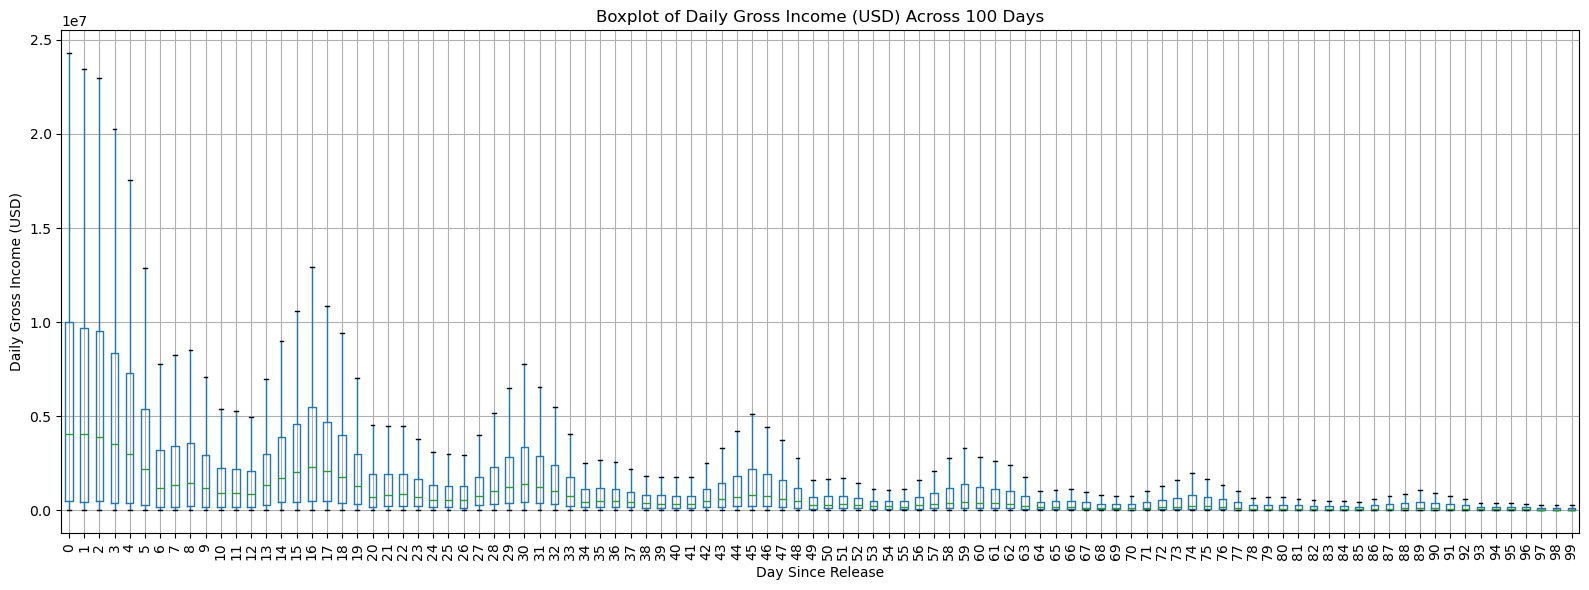

In [19]:
# Create a boxplot to show distribution of daily gross income across 100 days
plt.figure(figsize=(16, 6))
ts.iloc[:, :100].boxplot(showfliers=False)  # hide outliers for readability

plt.title("Boxplot of Daily Gross Income (USD) Across 100 Days")
plt.xlabel("Day Since Release")
plt.ylabel("Daily Gross Income (USD)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()


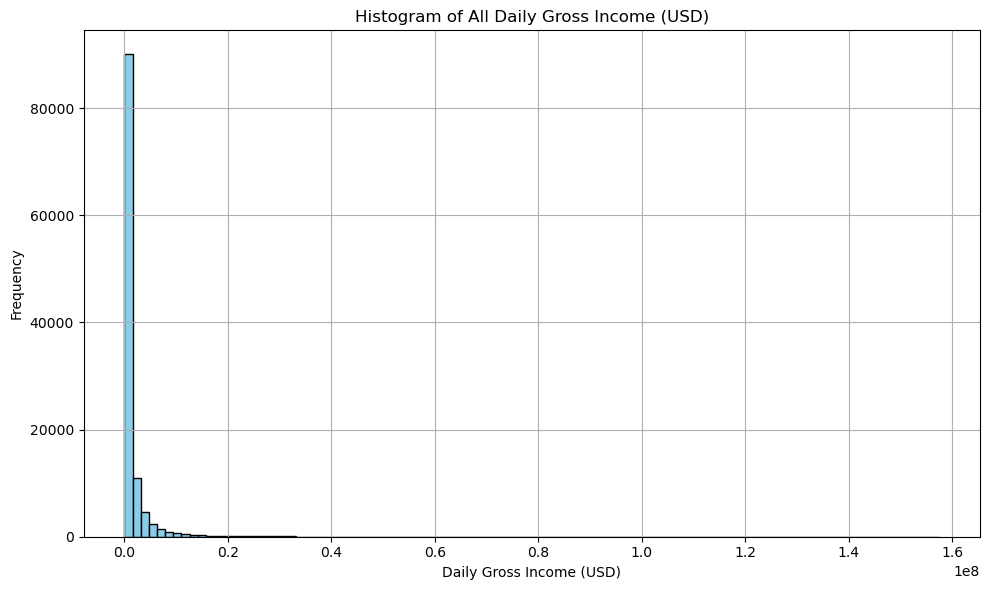

In [20]:
# Create a histogram of all daily gross values combined across all days and movies
plt.figure(figsize=(10, 6))
ts.values.flatten()  # Flatten to 1D array

plt.hist(ts.iloc[:, :100].values.flatten(), bins=100, color='skyblue', edgecolor='black')
plt.title("Histogram of All Daily Gross Income (USD)")
plt.xlabel("Daily Gross Income (USD)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


## Missing Values

In [21]:
missing_summary = ts.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

In [22]:
missing_summary 

Series([], dtype: int64)

## Anomalies

In [23]:
from sktime.transformations.series.func_transform import FunctionTransformer

### Hampel Filter

In [24]:
from sktime.transformations.series.outlier_detection import HampelFilter
from scipy.stats import median_abs_deviation

In [ ]:
# # Hampel Filter WITHOUT k (as per slide)
# def hampel_filter_no_k(ts_series, window_size=7, n_sigmas=3):
#     n = len(ts_series)
#     outliers = np.zeros(n, dtype=bool)
    
#     for i in range(n):
#         start = max(0, i - window_size // 2)
#         end = min(n, i + window_size // 2 + 1)
        
#         window = ts_series[start:end]
#         median = np.median(window)
#         mad = np.median(np.abs(window - median))

#         if mad == 0:
#             continue
        
#         if np.abs(ts_series[i] - median) > n_sigmas * mad:
#             outliers[i] = True

#     return outliers

In [30]:

def hampel_filter_with_k(ts_series, window_size=7, n_sigmas=3):
    n = len(ts_series)
    k = 1.4826
    outliers = np.zeros(n, dtype=bool)
    
    for i in range(n):
        start = max(0, i - window_size // 2)
        end = min(n, i + window_size // 2 + 1)
        
        window = ts_series[start:end]
        median = np.median(window)
        mad = np.median(np.abs(window - median))
        sigma = k * mad

        if sigma == 0:
            continue
        
        if np.abs(ts_series[i] - median) > n_sigmas * sigma:
            outliers[i] = True

    return outliers


# Apply Hampel Filter to each time series (each movie)
outlier_matrix = ts.apply(lambda row: hampel_filter_with_k(row.values), axis=1, result_type='expand')

# Count of outliers per movie
outlier_counts = outlier_matrix.sum(axis=1)

# Combine with movie metadata (rating, genre, etc.)
metadata = df.iloc[:, 100:]
outlier_summary = pd.concat([metadata, outlier_counts.rename('outlier_count')], axis=1)



In [31]:
# Filter only movies that have at least one outlier
movies_with_outliers = outlier_summary[outlier_summary['outlier_count'] > 0]

# For each movie, find the indices (days) where outliers occur
outlier_days = outlier_matrix.loc[movies_with_outliers.index].apply(lambda row: list(np.where(row)[0]), axis=1)
movies_with_outliers = movies_with_outliers.assign(outlier_days=outlier_days)

In [32]:
movies_with_outliers

,rating,genre,rating_category,outlier_count,outlier_days
id,,,,,
tt0062622,8.3,"['Adventure', 'Sci-Fi']",High,1,[53]
tt0088178,8.7,"['Documentary', 'Music']",High,3,"[71, 86, 87]"
tt0145487,7.4,"['Action', 'Adventure', 'Sci-Fi']",High,7,"[1, 14, 28, 43, 57, 72, 87]"
tt0359950,7.3,"['Adventure', 'Comedy', 'Drama']",High,2,"[1, 49]"
tt0437086,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,1,[25]
...,...,...,...,...,...
tt9487594,6.5,['Comedy'],Medium,1,[34]
tt9620288,7.5,"['Biography', 'Drama', 'Sport']",High,2,"[23, 79]"
tt9682428,4.7,"['Horror', 'Mystery', 'Thriller']",Medium Low,1,[37]


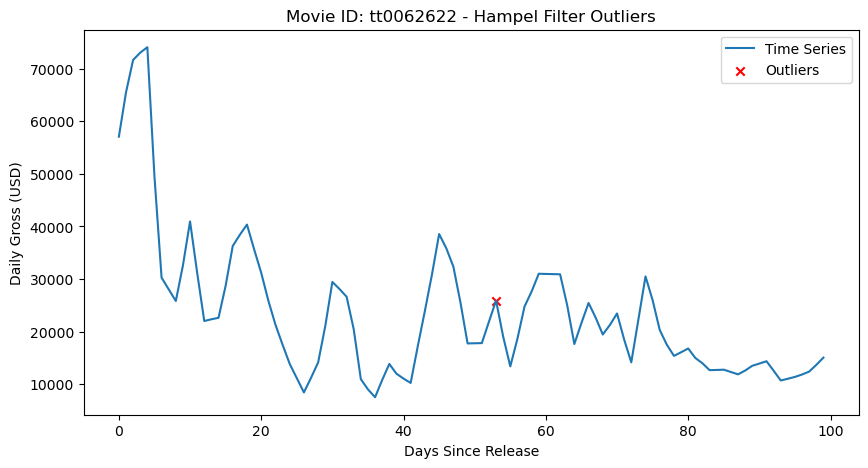

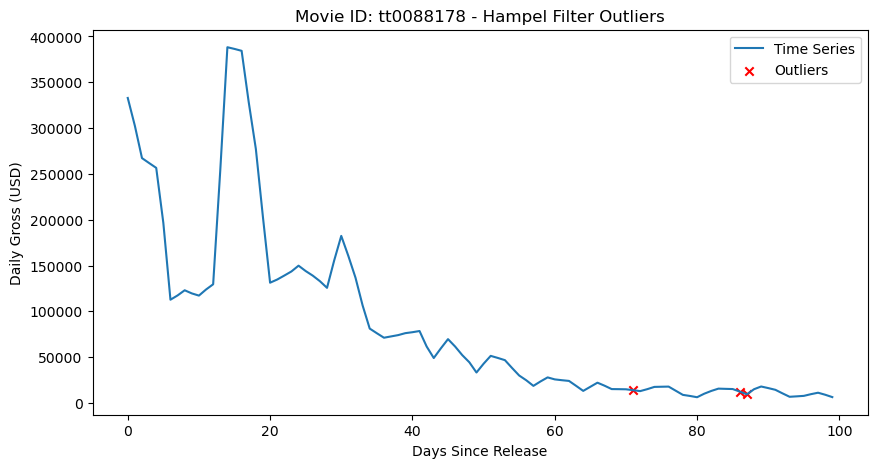

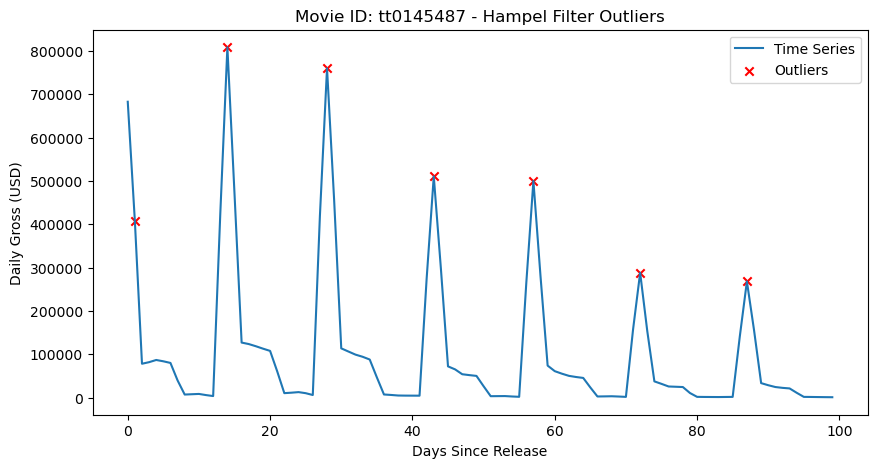

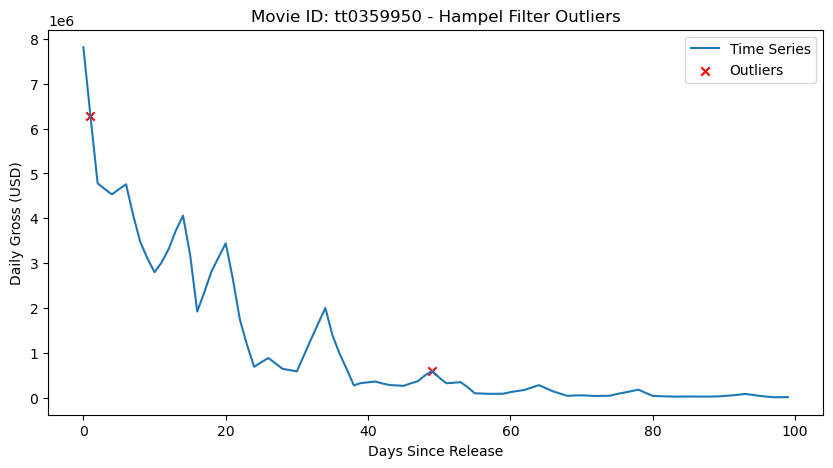

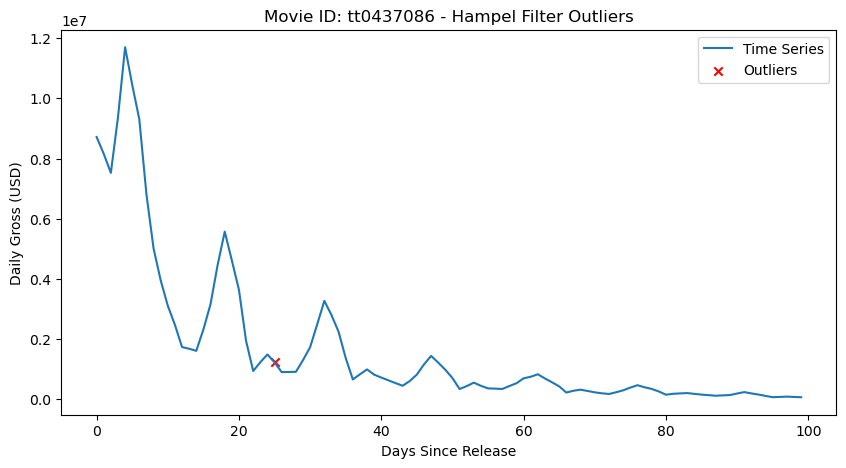

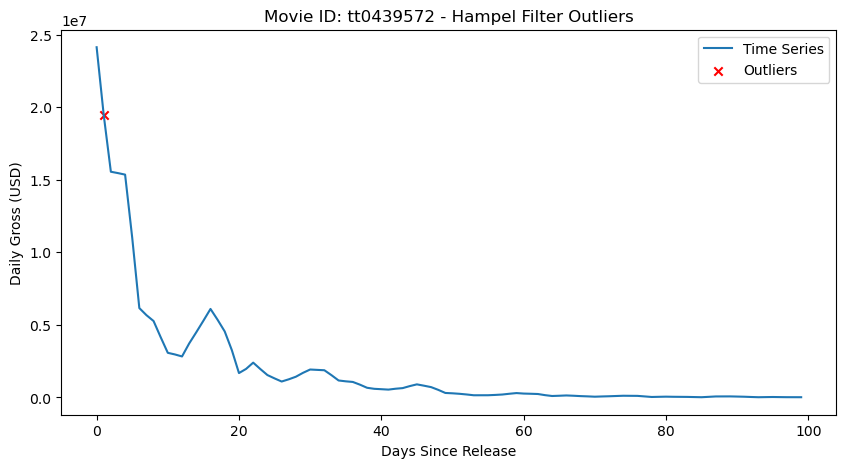

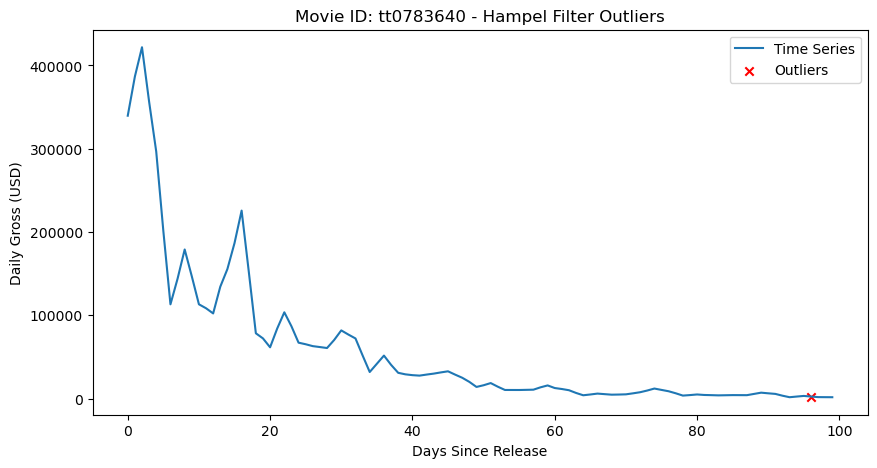

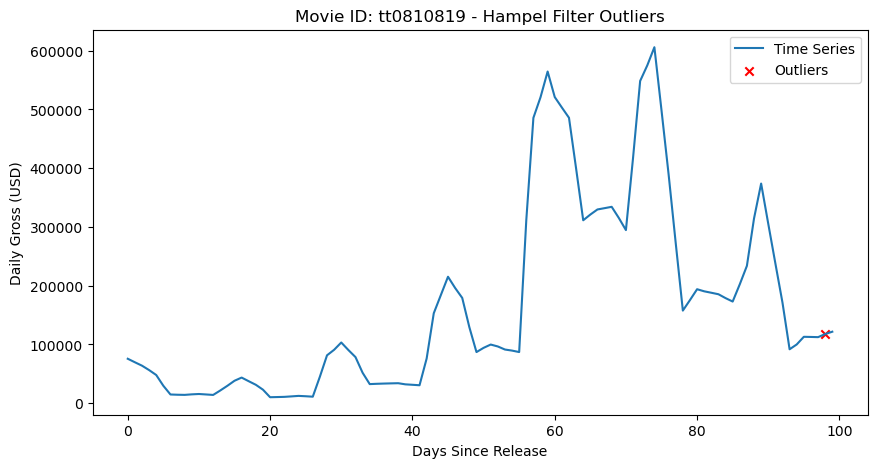

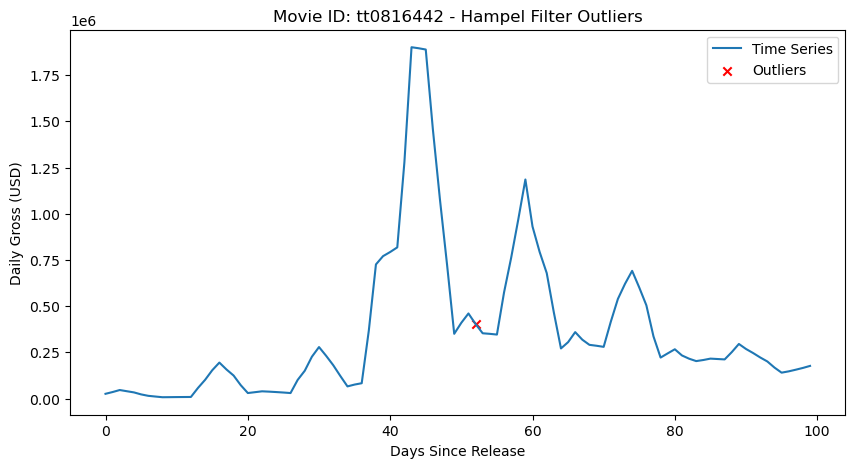

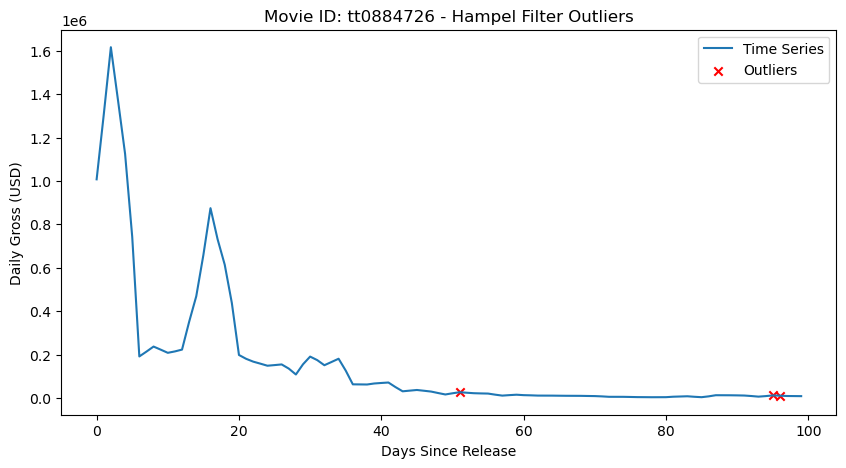

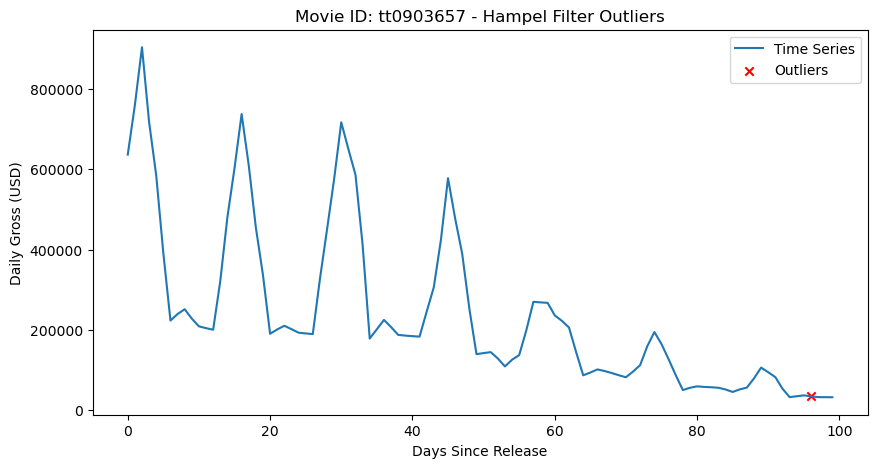

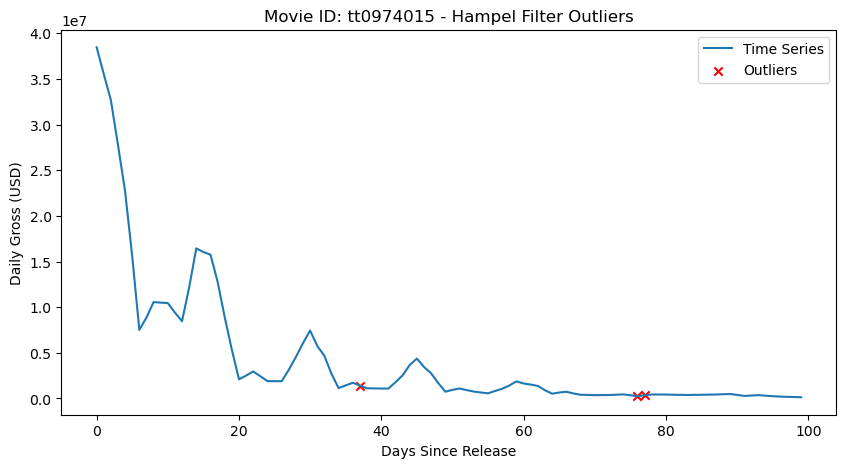

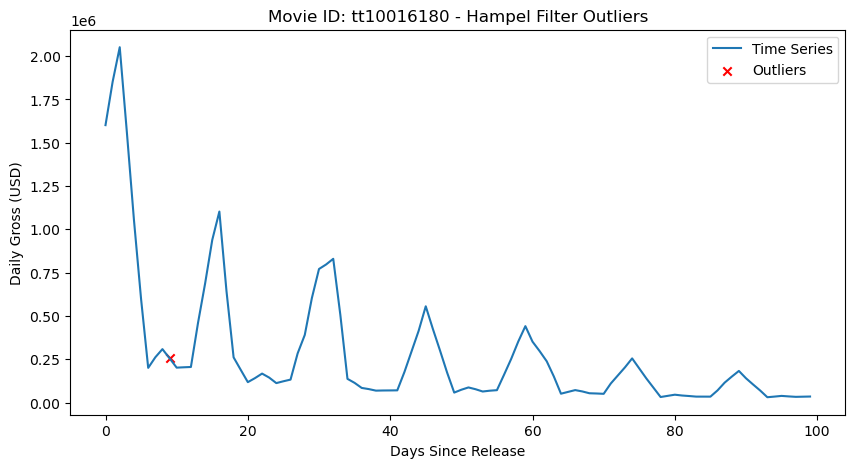

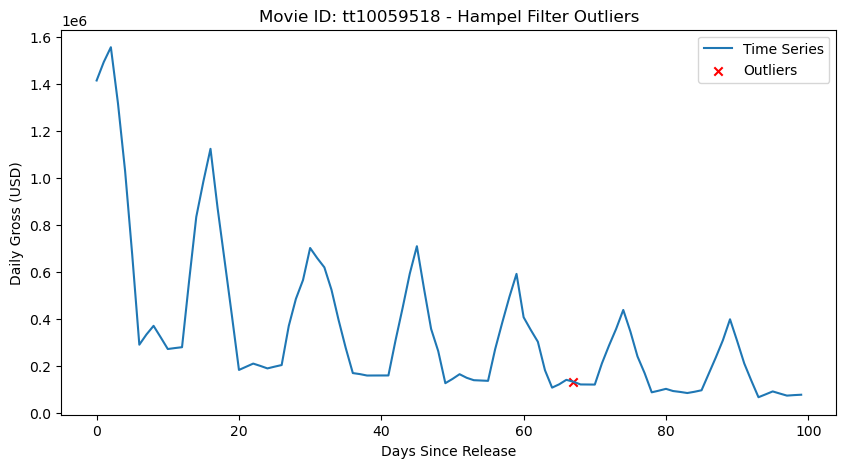

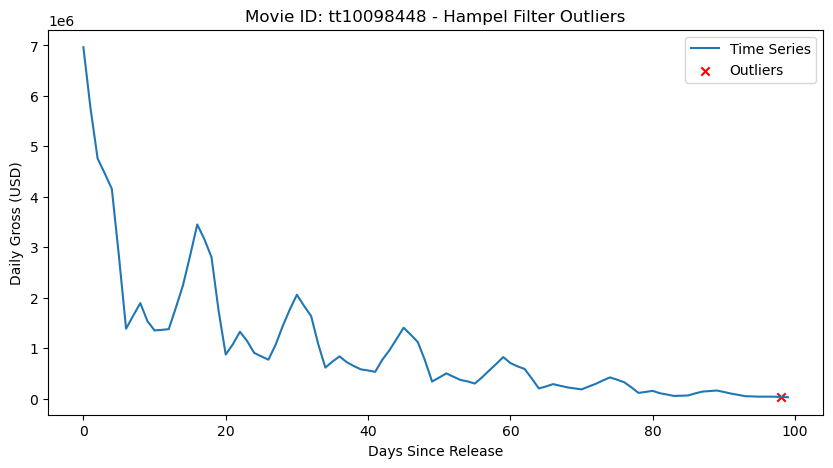

In [34]:
# Plot time series with outliers for movies with at least one outlier
for idx in movies_with_outliers.index[:15]:  # Limit to first 5 movies for visualization
    ts_series = ts.loc[idx].values
    outlier_indices = movies_with_outliers.loc[idx, 'outlier_days']
    
    plt.figure(figsize=(10, 5))
    plt.plot(ts_series, label='Time Series')
    plt.scatter(outlier_indices, ts_series[outlier_indices], color='red', label='Outliers', marker='x')
    plt.title(f'Movie ID: {idx} - Hampel Filter Outliers')
    plt.xlabel('Days Since Release')
    plt.ylabel('Daily Gross (USD)')
    plt.legend()
    plt.show()

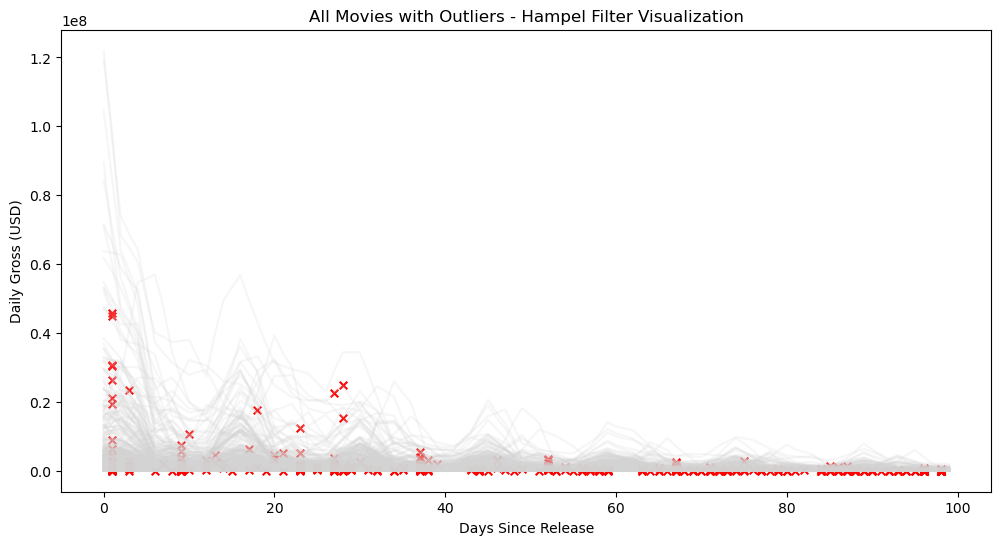

In [37]:
plt.figure(figsize=(12, 6))

# Plot all movies with outliers in a single plot
for idx in movies_with_outliers.index:
    ts_series = ts.loc[idx].values
    outlier_indices = movies_with_outliers.loc[idx, 'outlier_days']
    
    # Plot time series in light grey for context
    plt.plot(ts_series, color='lightgrey', alpha=0.2)
    
    # Plot outliers as red 'x'
    plt.scatter(outlier_indices, ts_series[outlier_indices], color='red', marker='x', s=30)

plt.title('All Movies with Outliers - Hampel Filter Visualization')
plt.xlabel('Days Since Release')
plt.ylabel('Daily Gross (USD)')
plt.show()


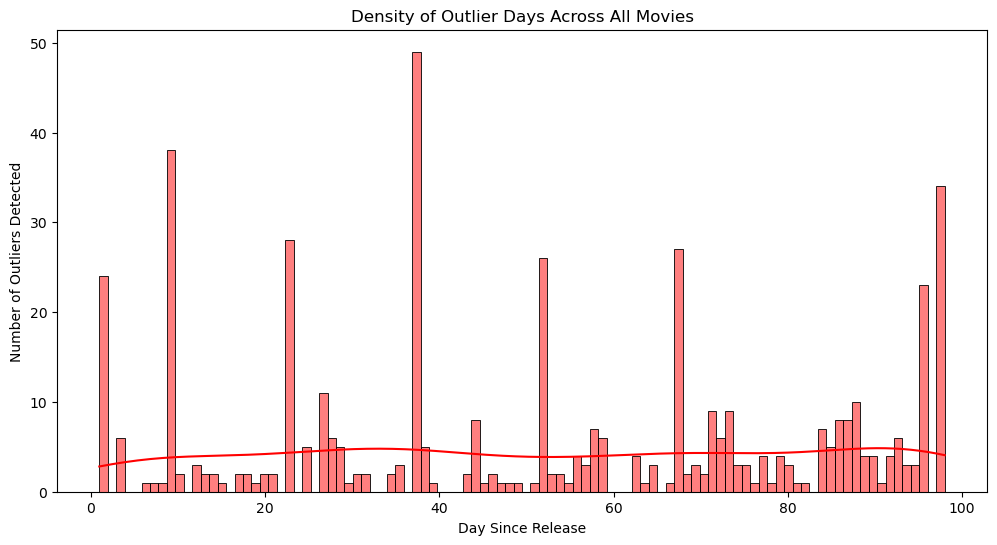

In [38]:
import seaborn as sns

# Collect all outlier day indices from all movies
all_outlier_days = [day for days in movies_with_outliers['outlier_days'] for day in days]

# Plot a density histogram of outlier days
plt.figure(figsize=(12, 6))
sns.histplot(all_outlier_days, bins=100, kde=True, color='red')
plt.title('Density of Outlier Days Across All Movies')
plt.xlabel('Day Since Release')
plt.ylabel('Number of Outliers Detected')
plt.show()


### Grubbs Test

In [39]:
from scipy import stats

In [41]:
# Redefine grubbs_test_indices function as it wasn't carried over in execution
from scipy.stats import t

def grubbs_test_indices(ts_series, alpha=0.05):
    data = ts_series.copy()
    original_indices = np.arange(len(data))
    outlier_indices = []
    n = len(data)
    
    while True:
        mean = np.mean(data)
        std_dev = np.std(data, ddof=1)
        G = np.max(np.abs(data - mean)) / std_dev
        max_idx_in_data = np.argmax(np.abs(data - mean))
        max_idx_original = original_indices[max_idx_in_data]
        
        # Compute critical value
        t_dist = t.ppf(1 - alpha / (2 * n), n - 2)
        critical_value = ((n - 1) / np.sqrt(n)) * np.sqrt(t_dist**2 / (n - 2 + t_dist**2))
        
        if G > critical_value:
            outlier_indices.append(max_idx_original)
            data = np.delete(data, max_idx_in_data)
            original_indices = np.delete(original_indices, max_idx_in_data)
            n -= 1
            if n < 3:
                break
        else:
            break
    
    return outlier_indices

# Re-run Grubbs' Test per time series (per movie) and collect outlier days
grubbs_outlier_days = {}

for idx, row in ts.iterrows():
    ts_series = row.values
    outlier_indices = grubbs_test_indices(ts_series)  # Per time series Grubbs' Test
    if outlier_indices:
        grubbs_outlier_days[idx] = outlier_indices


grubbs_outliers_df = pd.DataFrame(list(grubbs_outlier_days.items()), columns=['Movie ID', 'Outlier Days'])




In [43]:
# Extract metadata for movies detected with Grubbs' Test outliers
metadata = df.loc[grubbs_outliers_df['Movie ID']].iloc[:, 100:]

# Count of outliers
grubbs_outliers_df['Outlier Count'] = grubbs_outliers_df['Outlier Days'].apply(len)

# Combine all information
grubbs_outliers_full = pd.concat([grubbs_outliers_df.set_index('Movie ID'), metadata], axis=1).reset_index()

# Rename columns as requested
grubbs_outliers_full = grubbs_outliers_full.rename(columns={
    'index': 'Movie ID',
    'Outlier Count': 'outlier_count',
    'Outlier Days': 'outlier_days'
})

In [44]:
grubbs_outliers_full

,Movie ID,outlier_days,outlier_count,rating,genre,rating_category
0,tt0062622,"[4, 3, 2, 1, 0]",5,8.3,"['Adventure', 'Sci-Fi']",High
1,tt0064816,[59],1,7.1,"['Crime', 'Drama', 'Romance']",High
2,tt0145487,"[14, 28, 0]",3,7.4,"['Action', 'Adventure', 'Sci-Fi']",High
3,tt0359950,"[0, 1]",2,7.3,"['Adventure', 'Comedy', 'Drama']",High
4,tt0369610,"[0, 1, 2, 3, 4]",5,6.9,"['Action', 'Adventure', 'Sci-Fi']",Medium High
...,...,...,...,...,...,...
948,tt9682428,"[0, 1, 2, 3, 4, 16]",6,4.7,"['Horror', 'Mystery', 'Thriller']",Medium Low
949,tt9731534,"[0, 1, 2, 3, 4, 16, 5]",7,6.4,"['Horror', 'Mystery', 'Thriller']",Medium
950,tt9764362,"[0, 1, 2, 3]",4,7.2,"['Comedy', 'Horror', 'Thriller']",High
951,tt9784798,"[4, 3, 2, 1, 0, 5, 16, 15, 17, 18, 14, 30]",12,7.4,"['Biography', 'Drama', 'History']",High


In [42]:
grubbs_outliers_df

,Movie ID,Outlier Days
0,tt0062622,"[4, 3, 2, 1, 0]"
1,tt0064816,[59]
2,tt0145487,"[14, 28, 0]"
3,tt0359950,"[0, 1]"
4,tt0369610,"[0, 1, 2, 3, 4]"
...,...,...
948,tt9682428,"[0, 1, 2, 3, 4, 16]"
949,tt9731534,"[0, 1, 2, 3, 4, 16, 5]"
950,tt9764362,"[0, 1, 2, 3]"
951,tt9784798,"[4, 3, 2, 1, 0, 5, 16, 15, 17, 18, 14, 30]"


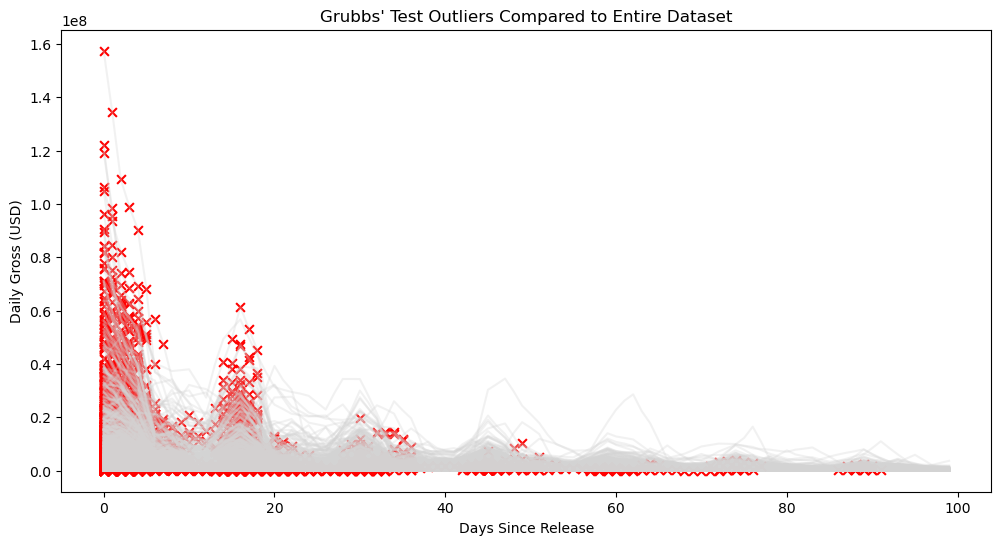

In [45]:
plt.figure(figsize=(12, 6))

# Plot all time series in light grey for context
for idx, row in ts.iterrows():
    plt.plot(row.values, color='lightgrey', alpha=0.3)

# Overlay Grubbs' Test outliers in red
for idx, outlier_days in grubbs_outlier_days.items():
    ts_series = ts.loc[idx].values
    plt.scatter(outlier_days, ts_series[outlier_days], color='red', marker='x', s=40)

plt.title("Grubbs' Test Outliers Compared to Entire Dataset")
plt.xlabel('Days Since Release')
plt.ylabel('Daily Gross (USD)')
plt.show()
